
# Importing required Python libraries for data analysis and machine learning

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# Loading the heart disease dataset from CSV file into pandas dataframe

In [22]:
df = pd.read_csv("data/heart.csv")
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


# Checking dataset shape, missing values, and target distribution

In [23]:
print(df.shape)
print(df.isnull().sum())
print(df['target'].value_counts())

(1025, 14)
age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64
target
1    526
0    499
Name: count, dtype: int64


# Visualizing age distribution of patients using histogram

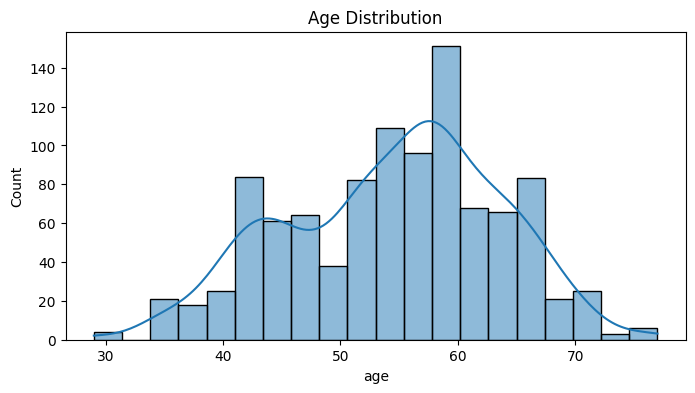

In [24]:
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Showing correlation between different features in dataset

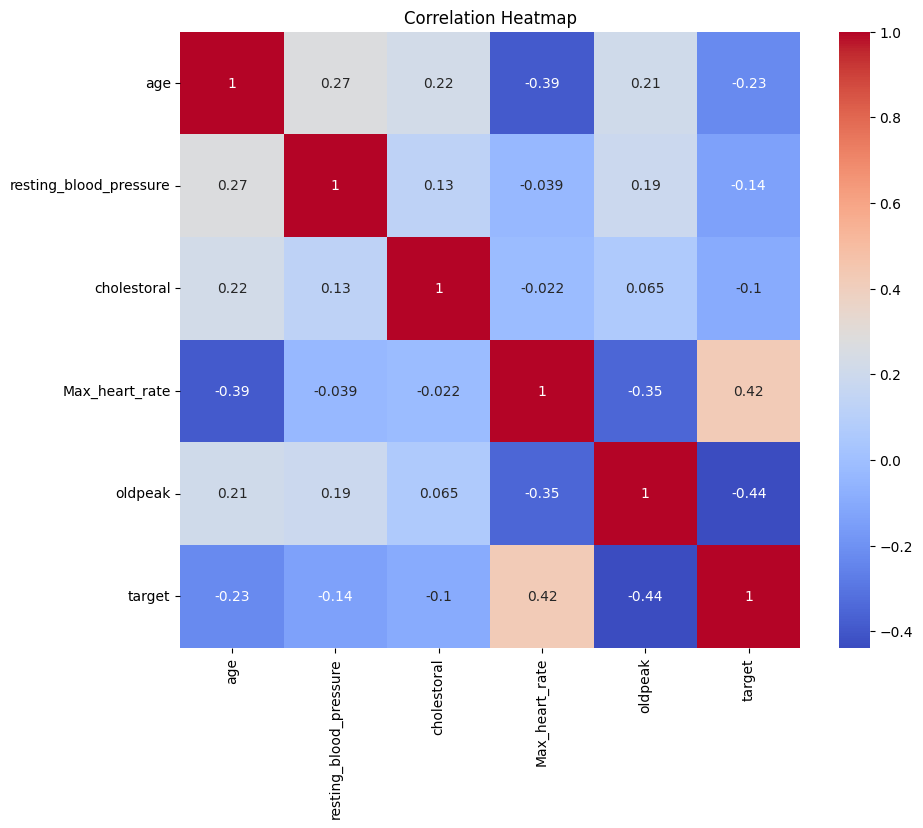

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Converting categorical variables into numerical format using one-hot encoding

In [26]:
df_encoded = pd.get_dummies(df, drop_first=True)

# Splitting dataset into training and testing sets (80% train, 20% test)

In [27]:
X = df_encoded.drop("target", axis=1)
y = df_encoded["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardizing features to improve model performance

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training Logistic Regression model for binary classification

In [29]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

# Making predictions on test dataset

In [30]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Evaluating model accuracy on unseen data

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7951219512195122


# Visualizing model performance using confusion matrix

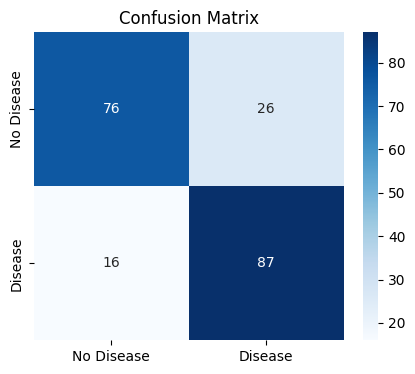

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease","Disease"],
            yticklabels=["No Disease","Disease"])
plt.title("Confusion Matrix")
plt.show()

# Plotting ROC curve to evaluate classification performance

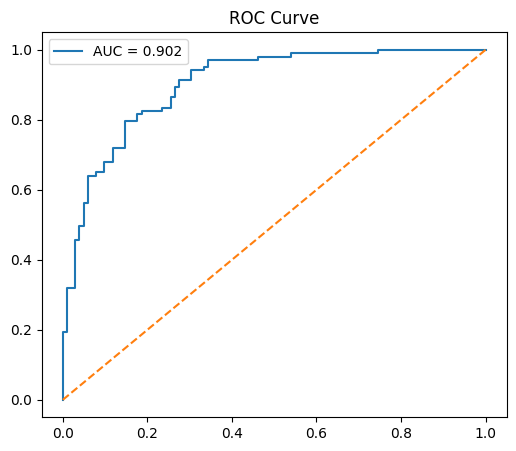

In [33]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.legend()
plt.show()

In [34]:
# Final conclusion of the project
print("Heart Disease Prediction Model Completed Successfully")
print("Model trained using Logistic Regression and evaluated using accuracy, confusion matrix, and ROC curve")

Heart Disease Prediction Model Completed Successfully
Model trained using Logistic Regression and evaluated using accuracy, confusion matrix, and ROC curve
